In [1]:
from datasets import load_dataset

# If you're running for the first time, uncomment the below line and download the dataset from the HF-Hub
# tiny_story_instruct_dataset = load_dataset('roneneldan/TinyStoriesInstruct')

### Expected Output ###
# Generating train split: 100%|██████████| 21755681/21755681 [00:09<00:00, 2394403.45 examples/s]
# Generating validation split: 100%|██████████| 218380/218380 [00:00<00:00, 844330.12 examples/s]
### Expected Output ###


/Users/sauravprateek/Documents/saurav-codes/neural-nets-codelab/saurav-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Uncomment below line to save the loaded dataset (from hf hub) to disk
# tiny_story_instruct_dataset.save_to_disk('./tiny-stories-instruct-dataset/')

### Expected Output ###
# Saving the dataset (6/6 shards): 100%|██████████| 21755681/21755681 [00:02<00:00, 10705866.06 examples/s]
# Saving the dataset (1/1 shards): 100%|██████████| 218380/218380 [00:00<00:00, 11119837.17 examples/s]
### Expected Output ###

In [133]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125M")

In [63]:
from datasets import load_from_disk

tokenized_story_summary_pairs = load_from_disk('./tiny-story-summary-tokenized')

In [78]:
tokenized_story_summary_pairs

Dataset({
    features: ['input_ids'],
    num_rows: 100000
})

In [79]:
print(len(tokenized_story_summary_pairs))

100000


In [109]:
print(tokenized_story_summary_pairs[1010])

{'input_ids': [11605, 25, 4874, 2402, 257, 640, 11, 612, 373, 257, 1263, 4074, 319, 262, 5417, 13, 383, 4074, 373, 523, 1263, 326, 340, 714, 3283, 6041, 286, 1243, 13, 1881, 1110, 11, 262, 4074, 2497, 257, 1402, 8848, 287, 262, 1660, 13, 383, 8848, 373, 523, 2705, 326, 340, 3114, 588, 257, 28774, 13, 383, 4074, 4438, 284, 1037, 262, 8848, 290, 3283, 340, 319, 663, 736, 13, 383, 8848, 373, 523, 3772, 290, 531, 5875, 345, 284, 262, 4074, 13, 383, 4074, 373, 3772, 284, 1037, 262, 8848, 290, 484, 2627, 922, 2460, 13, 220, 198, 22093, 25, 317, 1263, 4074, 5419, 257, 1402, 8848, 290, 484, 1716, 2460, 13, 50256]}


In [110]:
tokenizer.decode(tokenized_story_summary_pairs[1010])

'Story: Once upon a time, there was a big ship on the sea. The ship was so big that it could carry lots of things. One day, the ship saw a small boat in the water. The boat was so soft that it looked like a pillow. The ship offered to help the boat and carry it on its back. The boat was so happy and said thank you to the ship. The ship was happy to help the boat and they became good friends. \nSummary: A big ship helps a small boat and they become friends.<|endoftext|>'

In [67]:
from torch.optim import AdamW
from transformers import get_scheduler

# Standard learning rate for fine-tuning
learning_rate = 5e-5
num_epochs = 3

# Load model from hugging face
model_id = 'SauravP97/tiny-stories-19M'
pretrained_model = AutoModelForCausalLM.from_pretrained(model_id)

optimizer = AdamW(pretrained_model.parameters(), lr=learning_rate)

# Calculate total training steps
num_training_steps = num_epochs * len(tokenized_story_summary_pairs)

# Set up the learning rate scheduler
lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

Loading weights: 100%|██████████| 108/108 [00:00<00:00, 806.46it/s, Materializing param=transformer.wte.weight]


In [81]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class TinyStoryDataset(Dataset):
    def __init__(self, tokenized_list):
        self.data = tokenized_list['input_ids']
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long)

In [82]:
tokenized_dataset = TinyStoryDataset(tokenized_story_summary_pairs)

In [134]:
tokenizer.pad_token_id, tokenizer.eos_token_id

(None, 50256)

In [135]:
print('Added special pad token ID')
tokenizer.pad_token = '...'

Added special pad token ID


In [137]:
tokenizer.pad_token_id, tokenizer.pad_token

(986, '...')

In [138]:
tokenizer.vocab_size

50257

In [139]:
tokenizer.special_tokens_map

{'bos_token': '<|endoftext|>',
 'eos_token': '<|endoftext|>',
 'unk_token': '<|endoftext|>',
 'pad_token': '...'}

In [141]:

def dynamic_collate_fn(batch):
    pad_token_id = tokenizer.pad_token_id
    
    # 1. Pad the sequences so they all match the longest one in this batch
    padded_input_ids = pad_sequence(batch, batch_first=True, padding_value=pad_token_id)
    
    # 2. For Causal LM, labels are a direct copy of the input_ids
    labels = padded_input_ids.clone()
    
    # 3. Dynamically create the attention mask
    # It creates a tensor of 1s where the token is real, and 0s where it is padding
    attention_masks = (padded_input_ids != pad_token_id).long()

    # 4. Replace padding token ids in labels with -100 to ignore them in loss calculation
    labels[labels == pad_token_id] = -100
    
    # 3. Return the neat dictionary that standard NLP models expect
    return {
        'input_ids': padded_input_ids,
        'attention_mask': attention_masks,
        'labels': labels
    }

In [142]:
train_dataloader = DataLoader(
    tokenized_dataset, 
    batch_size=8, 
    shuffle=True, 
    collate_fn=dynamic_collate_fn
)

In [143]:
first_batch = next(iter(train_dataloader))

In [144]:
first_batch['input_ids'].shape, first_batch['attention_mask'].shape, first_batch['labels'].shape

(torch.Size([8, 555]), torch.Size([8, 555]), torch.Size([8, 555]))

In [145]:
print(tokenizer.decode(first_batch['input_ids'].tolist()[0]))
print('\n')
print(tokenizer.decode([label if label != -100 else tokenizer.pad_token_id for label in first_batch['labels'].tolist()[0]]))

Story: Ben and Lily were playing with their toys in the garden. They liked to examine their toys and see how they worked. Ben had a blue car that could go fast and make noises. Lily had a doll that could talk and sing. They decided to have a race with their toys. They made a track with some stones and sticks. They said "ready, set, go!" and pushed their toys along the track. Ben's car zoomed ahead of Lily's doll. He was happy and shouted "I win! I win!" Lily was sad and said "No fair! Your car is faster than my doll. You have a better score than me." She started to cry and hugged her doll. Ben saw that Lily was sad and felt sorry for her. He said "Don't cry, Lily. It's just a game. We can play something else. Do you want to swap toys for a while? You can have my car and I can have your doll." Lily stopped crying and smiled. She said "Really? Can I try your car? It looks fun." She gave her doll to Ben and took his car. She examined the car and pressed the buttons. The car made noises an

In [ ]:
from tqdm.auto import tqdm

progress_bar = tqdm(range(num_training_steps), desc="Training")
pretrained_model.train() # Put model in training mode

losses = []

for epoch in range(num_epochs):
    for batch in train_dataloader:
        if batch['input_ids'].shape[1] > 511:
            continue

        # Move all tensors in the batch to the designated device
        batch = {k: v for k, v in batch.items()}
        
        # 1. Forward pass
        outputs = pretrained_model(**batch)
        loss = outputs.loss
        
        # 2. Backward pass
        loss.backward()
        losses.append(loss)
        
        # 3. Update weights and learning rate
        optimizer.step()
        lr_scheduler.step()
        
        # 4. Clear gradients for the next step
        optimizer.zero_grad()
        
        # Update progress bar and print loss
        progress_bar.update(1)
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

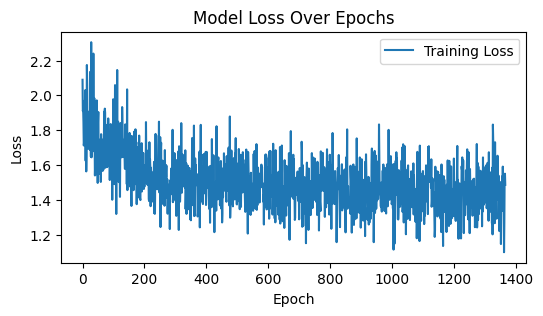

In [147]:
import matplotlib.pyplot as plt

def plot_loss_curve(losses):
    loss_list = [loss.item() for loss in losses]

    # Plot the loss curve
    plt.figure(figsize=(6, 3)) # Optional: adjust figure size
    plt.plot(loss_list, label='Training Loss')

    # Add titles and labels
    plt.title('Model Loss Over Epochs')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend() # Show the legend

    # Display the plot
    plt.show()

plot_loss_curve(losses)

In [100]:
pretrained_model

GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 256)
    (wpe): Embedding(512, 256)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-7): 8 x GPTNeoBlock(
        (ln_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=256, out_features=256, bias=False)
            (v_proj): Linear(in_features=256, out_features=256, bias=False)
            (q_proj): Linear(in_features=256, out_features=256, bias=False)
            (out_proj): Linear(in_features=256, out_features=256, bias=True)
          )
        )
        (ln_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=256, out_features=1024, bias=True)
          (c_proj): Linear(in_featu

In [157]:
story_summary_prompt = tokenizer.decode(tokenized_dataset[8000])
story_summary_prompt.split('\nSummary: ')[0].strip()

'Story: Once upon a time, there was a dish that could sail. It was a very special dish. It was not too big or too small. It was just right. One day, the dish met a hard rock. The hard rock was sad because it could not move. "Hello, hard rock," said the dish. "Why are you so sad?" "I cannot move," said the hard rock. "I want to see the world, but I am stuck here." The dish had an idea. "I can help you, hard rock. I can sail, and you can come with me. We can see the world together." The hard rock was very happy. It got on the dish, and they sailed away. They saw many things and had lots of fun. The dish and the hard rock became the best of friends. And they lived happily ever after.'

In [163]:
# Move model to evaluation mode
pretrained_model.eval()

# Prompt with a typical TinyStories opening
story_summary_prompt = tokenizer.decode(tokenized_dataset[8001])
story_prompt = story_summary_prompt.split('\nSummary: ')[0].strip()
prompt = story_prompt + '\nSummary: '
inputs = tokenizer(prompt, return_tensors="pt")

In [164]:
prompt

'Story: One evening, a little boy named Tim went to the park with his mom. The sun was going down and the sky was wide and pretty. Tim saw a big, red ball near the swings. He wanted to play with it. "Mom, can I lift the ball, please?" Tim asked. His mom smiled and said, "Yes, you can lift it, Tim." Tim tried to lift the big, red ball. It was heavy, but he lifted it high. He threw the ball and it bounced away. Tim ran after it, laughing. He played with the ball until the stars came out. It was a fun evening at the park.\nSummary: '

In [165]:
inputs['input_ids'].shape

torch.Size([1, 139])

In [ ]:
# Generate
output_tokens = pretrained_model.generate(
    inputs.input_ids,
    max_new_tokens=100, 
    do_sample=True,
    temperature=1, 
    top_k=50,
    pad_token_id=tokenizer.eos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

In [167]:
tokenizer.decode(output_tokens)

['Story: One evening, a little boy named Tim went to the park with his mom. The sun was going down and the sky was wide and pretty. Tim saw a big, red ball near the swings. He wanted to play with it. "Mom, can I lift the ball, please?" Tim asked. His mom smiled and said, "Yes, you can lift it, Tim." Tim tried to lift the big, red ball. It was heavy, but he lifted it high. He threw the ball and it bounced away. Tim ran after it, laughing. He played with the ball until the stars came out. It was a fun evening at the park.\nSummary:  Tim wants to climb a big, red sky with a big, red ball, but he can\'t reach it. When his mom helps him, the ball goes back to him, but he sees a giant hill behind him. Tim asks his dad to help him climb the hill, and they climb the hill together. Tim is happy to see a giant hill and has lots of fun.<|endoftext|>']